# Live-Betting Player Churn Prediction
## Complete Project Presentation

---

### The Business Problem

A live-betting platform wants to know — **before it happens** — which players are about to stop placing bets.  
With that list, the retention team can send targeted offers, bonuses, or re-engagement campaigns to the highest-risk players first.

**Definition of churn:** a player who places **zero live bets** in the 30 days after the snapshot date (2025-12-31).

**Observation window:** 2025-10-03 → 2025-12-31 (90 days of behaviour used as input features).

---

### Project Scope — What Was Tested

| Phase | What | Outcome |
|-------|------|---------|
| Data investigation | Leakage detection, missingness, cleaning strategy | Critical leakage found and removed |
| EDA | Correlations, distributions, churn rates by segment | Engagement features dominate; win/loss is noise |
| Modelling | 4 models: heuristic, LogReg, LightGBM, XGBoost | LogReg wins on all metrics |
| Hyperparameter tuning | Full grid search (LogReg) + random search (XGBoost) | Baseline LogReg already near-optimal |
| Feature engineering | Raw (13) vs engineered (21) vs +11 new vs +7 proposed | Engineering adds +0.002 ROC-AUC; new features add nothing more |
| Interpretation | SHAP, LogReg coefficients, gain importance | Consistent driver story across all models |
| Business evaluation | Decile lift, calibration, threshold analysis | Top 30% captures 74% of churners at 2.6× avg precision |

---

### Headline Results

| Metric | Value |
|--------|-------|
| Best model | **Logistic Regression** (L2, C=1.0) |
| Held-out ROC-AUC | **0.854** |
| Held-out PR-AUC | **0.537** (base rate 17.3%) |
| Calibration (Brier) | **0.106** — probabilities trustworthy |
| Top decile lift | **3.5×** — 60% churn rate vs 17.3% average |
| Top 30% recall | **74%** of all churners captured |

---
## Part 1 — Setup

In [1]:
from __future__ import annotations
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_validate, StratifiedKFold, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix,
                             classification_report)
from sklearn.calibration import calibration_curve
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
%matplotlib inline

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white",
})
ACCENT, ACCENT2, GREEN, ORANGE, MUTED = "#2563eb", "#dc2626", "#059669", "#d97706", "#64748b"
FIG = "figures_presentation"
os.makedirs(FIG, exist_ok=True)
print("Setup complete.")

Setup complete.


---
## Part 2 — Data Investigation

### 2.1 Leakage Detection

The raw dataset contains `live_bets_count_outcome_window` — the number of bets placed **after** the observation window.  
This column equals the target by construction: if a player placed 0 outcome bets they are churned.  
Using it would produce a perfect but useless model. **It must be dropped.**

In [2]:
_HERE = os.path.abspath("")
ROOT = os.path.abspath(os.path.join(_HERE, os.pardir))
RAW_PATH = (
    os.environ.get("CHURN_DATA")
    or os.path.join(ROOT, "data", "raw", "churn_dataset.csv")
)
DATE_COLS = ["registration_date","observation_start_date","observation_end_date",
             "last_live_bet_date","first_live_bet_date"]
raw = pd.read_csv(RAW_PATH, parse_dates=DATE_COLS)

# PROOF: leakage
leak, target = raw["live_bets_count_outcome_window"], raw["churn"]
print(f"Dataset: {raw.shape[0]:,} players × {raw.shape[1]} raw columns")
print(f"Churn rate: {target.mean():.1%}  ({int(target.sum()):,} churned)")
print()
print("LEAKAGE CHECK — outcome_window vs churn label:")
print(pd.crosstab((leak==0).rename("outcome==0"), target.rename("churn")))
print(f"Perfect match: {((leak==0)==(target==1)).all()}  → column dropped")

Dataset: 10,000 players × 21 raw columns
Churn rate: 17.3%  (1,728 churned)

LEAKAGE CHECK — outcome_window vs churn label:
churn          0     1
outcome==0            
False       8272     0
True           0  1728
Perfect match: True  → column dropped


### 2.2 Cleaning Decisions

**Cleaning decisions:**
- `avg_bet_amount` is reconstructed exactly as `total_turnover / live_bets_count` for the 690 rows where it is missing — no information is lost.
- Deposit fields missing for ~502 players are filled with 0 and flagged with `no_deposit_flag` (these players churn slightly less, so missingness is informative).

In [3]:
# Missing data
miss = raw.isna().sum(); miss = miss[miss>0].sort_values(ascending=False)
print("Missing values:")
print(miss.to_string())

# avg_bet_amount: exact reconstruction
recomp = raw["total_turnover"] / raw["live_bets_count"].replace(0, np.nan)
n_recoverable = (raw["avg_bet_amount"].isna() & recomp.notna()).sum()
max_diff = (raw.loc[raw["avg_bet_amount"].notna() & (raw["live_bets_count"]>0), "avg_bet_amount"] -
            recomp[raw["avg_bet_amount"].notna() & (raw["live_bets_count"]>0)]).abs().max()
print(f"\navg_bet_amount: {raw['avg_bet_amount'].isna().sum()} missing → {n_recoverable} reconstructed "
      f"exactly (max error = {max_diff:.6f})")

# Deposit flag is informative
churn_dep = raw.groupby(raw["deposit_count"].isna())["churn"].mean()
print(f"\nChurn rate — has deposit: {churn_dep[False]:.1%} | no deposit: {churn_dep[True]:.1%}  "
      f"(no-deposit players churn less → flag kept as feature)")

Missing values:
avg_bet_amount               690
deposit_to_turnover_ratio    503
deposit_count                502
total_deposit_amount         502
last_live_bet_date             1
first_live_bet_date            1
ggr_margin                     1

avg_bet_amount: 690 missing → 689 reconstructed exactly (max error = 0.000000)

Churn rate — has deposit: 17.4% | no deposit: 14.1%  (no-deposit players churn less → flag kept as feature)


---
## Part 3 — Feature Engineering

Starting from **13 raw columns**, 8 behavioural features were engineered — each mapping to one RFM lever.

| Feature | RFM lever | Intuition |
|---------|-----------|----------|
| `bets_per_active_day` | Frequency | Intensity per session — habit strength |
| `active_span_days` | Recency | How long they stayed engaged in the window |
| `activity_consistency` | Frequency | Spread evenly vs sporadic bursts |
| `days_to_first_bet` | Recency | Late first bet → weak engagement from start |
| `lifetime_bet_rate` | Frequency | Bets per day of account tenure |
| `turnover_per_active_day` | Monetary | Value intensity per session |
| `avg_deposit_amount` | Monetary | Average deposit size |
| `deposit_per_bet` | Monetary | Cash commitment per bet |

In [4]:
DROP = ["live_bets_count_outcome_window","observation_start_date","observation_end_date",
        "user_id","bet_day_rate","registration_date","last_live_bet_date",
        "first_live_bet_date","churn"]
LOG_COLS = ["total_turnover","total_payout","total_deposit_amount",
            "turnover_per_active_day","avg_deposit_amount","deposit_per_bet","live_bets_count"]
OBS = 90

def build_dataset(path=RAW_PATH):
    raw = pd.read_csv(path, parse_dates=DATE_COLS)
    df  = raw.copy()
    df["avg_bet_amount"]  = df["avg_bet_amount"].fillna(
        df["total_turnover"] / df["live_bets_count"].replace(0,np.nan)).fillna(0.0)
    df["no_deposit_flag"] = df["deposit_count"].isna().astype(int)
    for c in ["deposit_count","total_deposit_amount","deposit_to_turnover_ratio"]:
        df[c] = df[c].fillna(0.0)
    df["ggr_margin"] = df["ggr_margin"].fillna(0.0)
    eps = 1.0
    df["bets_per_active_day"]     = df["live_bets_count"] / (df["days_active_in_observation"] + eps)
    df["active_span_days"]        = (df["last_live_bet_date"]-df["first_live_bet_date"]).dt.days.fillna(0.0)
    df["activity_consistency"]    = df["days_active_in_observation"] / (df["active_span_days"] + eps)
    df["days_to_first_bet"]       = ((df["first_live_bet_date"]-pd.Timestamp("2025-10-03")).dt.days.fillna(OBS))
    df["lifetime_bet_rate"]       = df["live_bets_count"] / (df["tenure_days"] + eps)
    df["turnover_per_active_day"] = df["total_turnover"] / (df["days_active_in_observation"] + eps)
    df["avg_deposit_amount"]      = df["total_deposit_amount"] / (df["deposit_count"] + eps)
    df["deposit_per_bet"]         = df["total_deposit_amount"] / (df["live_bets_count"] + eps)
    feats = [c for c in df.columns if c not in DROP]
    return raw, df, df[feats].copy(), df["churn"].astype(int).copy(), feats

raw, full, X, y, feats = build_dataset()
print(f"Raw features   : 13")
print(f"After engineering: {len(feats)} features")
print(f"Remaining NaNs : {X.isna().sum().sum()}")

Raw features   : 13
After engineering: 21 features
Remaining NaNs : 0


---
## Part 4 — Exploratory Data Analysis

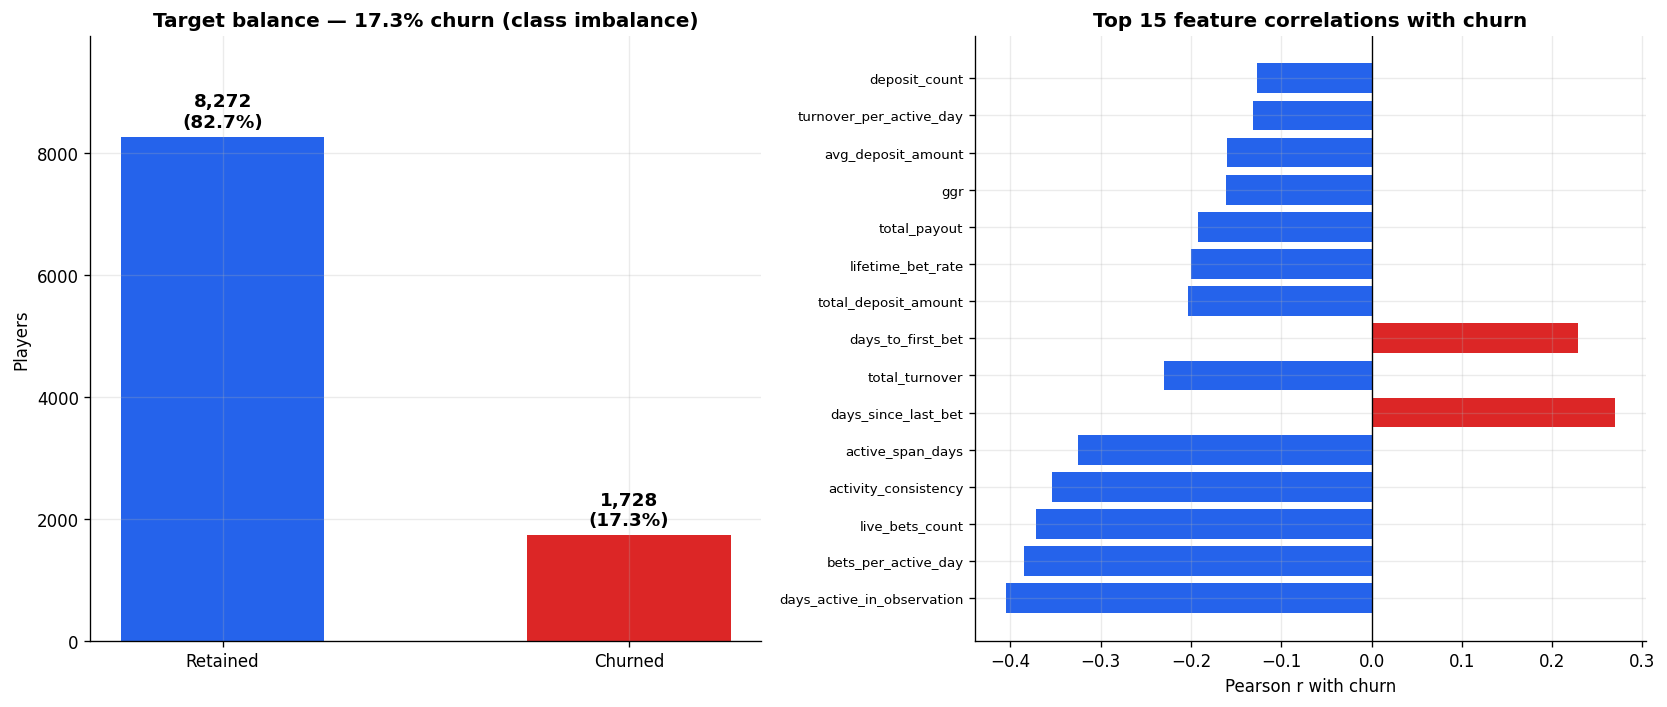

In [5]:
# Target balance + feature correlations side by side
corr = full[feats+["churn"]].corr()["churn"].drop("churn").sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: target balance
counts = y.value_counts().sort_index()
bars = axes[0].bar(["Retained","Churned"], counts.values, color=[ACCENT,ACCENT2], width=0.5)
for b,v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+100, f"{v:,}\n({v/len(y):.1%})",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Target balance — 17.3% churn (class imbalance)")
axes[0].set_ylabel("Players"); axes[0].set_ylim(0, counts.max()*1.2)

# Right: top-15 correlations
top = corr.head(15)
axes[1].barh(range(len(top)), top.values,
             color=[ACCENT2 if v>0 else ACCENT for v in top.values])
axes[1].set_yticks(range(len(top))); axes[1].set_yticklabels(top.index, fontsize=8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Pearson r with churn")
axes[1].set_title("Top 15 feature correlations with churn")
fig.tight_layout(); fig.savefig(f"{FIG}/01_eda_overview.png"); plt.show()

In [6]:
# Engagement vs Win/Loss — the key EDA finding
engagement = ["days_active_in_observation","bets_per_active_day",
              "live_bets_count","activity_consistency",
              "days_since_last_bet","days_to_first_bet"]
winloss    = ["ggr","ggr_margin","total_payout","avg_bet_amount"]

print("ENGAGEMENT features — Pearson r with churn:")
for f in engagement:
    bar = "█" * int(abs(corr[f])*40)
    print(f"  {f:<35} {corr[f]:+.3f}  {bar}")
print()
print("WIN/LOSS features — Pearson r with churn:")
for f in winloss:
    bar = "█" * int(abs(corr[f])*40)
    print(f"  {f:<35} {corr[f]:+.3f}  {bar}")
print()
print(f"Conclusion: engagement features are {corr[engagement].abs().max()/corr[winloss].abs().max():.0f}× "
      f"stronger than win/loss features.")
print("Whether a player wins or loses money does NOT drive short-term churn.")

ENGAGEMENT features — Pearson r with churn:
  days_active_in_observation          -0.405  ████████████████
  bets_per_active_day                 -0.385  ███████████████
  live_bets_count                     -0.372  ██████████████
  activity_consistency                -0.354  ██████████████
  days_since_last_bet                 +0.270  ██████████
  days_to_first_bet                   +0.229  █████████

WIN/LOSS features — Pearson r with churn:
  ggr                                 -0.162  ██████
  ggr_margin                          +0.012  
  total_payout                        -0.193  ███████
  avg_bet_amount                      -0.002  

Conclusion: engagement features are 2× stronger than win/loss features.
Whether a player wins or loses money does NOT drive short-term churn.


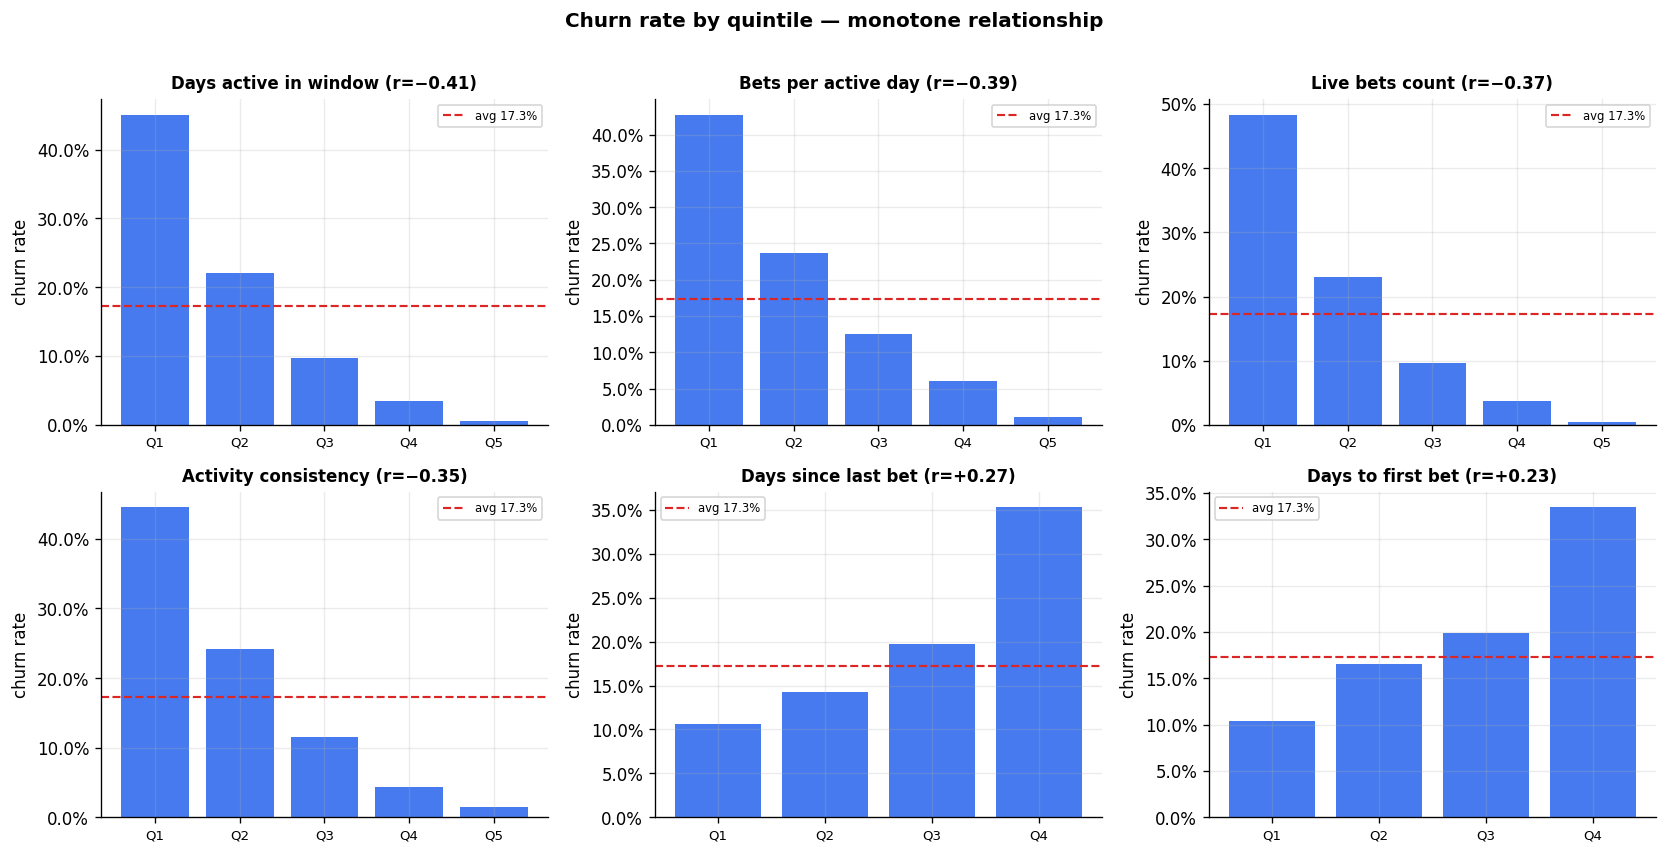

In [7]:
# Churn rate by quintile — the 6 strongest predictors
base = y.mean()
panels = [("days_active_in_observation","Days active in window (r=−0.41)"),
          ("bets_per_active_day",       "Bets per active day (r=−0.39)"),
          ("live_bets_count",           "Live bets count (r=−0.37)"),
          ("activity_consistency",      "Activity consistency (r=−0.35)"),
          ("days_since_last_bet",       "Days since last bet (r=+0.27)"),
          ("days_to_first_bet",         "Days to first bet (r=+0.23)")]
fig, axes = plt.subplots(2,3, figsize=(14,7)); axes=axes.ravel()
for axn,(col,label) in zip(axes,panels):
    d = full[[col]].copy(); d["churn"] = y.values
    try:    d["bin"] = pd.qcut(d[col], 5, duplicates="drop")
    except: d["bin"] = pd.cut(d[col], 5)
    g = d.groupby("bin", observed=True)["churn"].mean()
    axn.bar(range(len(g)), g.values, color=ACCENT, alpha=0.85)
    axn.axhline(base, color=ACCENT2, ls="--", lw=1.3, label=f"avg {base:.1%}")
    axn.set_xticks(range(len(g)))
    axn.set_xticklabels([f"Q{i+1}" for i in range(len(g))], fontsize=8)
    axn.set_title(label, fontsize=10); axn.set_ylabel("churn rate")
    axn.legend(fontsize=7); axn.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
fig.suptitle("Churn rate by quintile — monotone relationship",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{FIG}/02_churn_by_quintile.png"); plt.show()

---
## Part 5 — Model Training and CV Stability

**Four models** tested in order of complexity. All hyperparameters except the initial baseline use values selected through cross-validation.

**Validation strategy:** 5-fold × 3-repeat stratified CV on the **training set only** (15 fits per model).  
The 20% held-out test set is touched exactly once at the end.

In [8]:
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, y, X.index, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}  |  Churn rate: {y.mean():.1%}")

def build_logreg(C=1.0, penalty="l2", solver="saga", l1_ratio=None, class_weight=None):
    log_c = [c for c in LOG_COLS if c in feats]
    other = [c for c in feats if c not in log_c]
    pre = ColumnTransformer([
        ("log", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("sc",  StandardScaler())]), log_c),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), other),
    ])
    kw = dict(C=C, max_iter=3000, penalty=penalty, solver=solver,
              class_weight=class_weight, random_state=RANDOM_STATE)
    if l1_ratio is not None: kw["l1_ratio"] = l1_ratio
    return Pipeline([("pre", pre), ("clf", LogisticRegression(**kw))])

def build_lgbm(num_leaves=7):
    return LGBMClassifier(n_estimators=1500, learning_rate=0.02, num_leaves=num_leaves,
                          min_child_samples=60, subsample=0.85, subsample_freq=1,
                          colsample_bytree=0.8, reg_lambda=3.0,
                          random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

# Train XGBoost on a CUDA GPU when one is present; fall back to CPU so the
# notebook stays portable on machines without an NVIDIA card.
def _xgb_gpu_available():
    try:
        XGBClassifier(tree_method="hist", device="cuda", n_estimators=1).fit(
            np.zeros((8, 2)), np.array([0, 1] * 4))
        return True
    except Exception:
        return False

XGB_DEVICE = "cuda" if _xgb_gpu_available() else "cpu"
print(f"XGBoost training device -> {XGB_DEVICE}")

def build_xgb():
    return XGBClassifier(n_estimators=1500, learning_rate=0.02, max_depth=3,
                         min_child_weight=60, subsample=0.85, colsample_bytree=0.8,
                         reg_lambda=3.0, eval_metric="logloss", use_label_encoder=False,
                         tree_method="hist", device=XGB_DEVICE,
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

cv      = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
scoring = {"roc_auc":"roc_auc","pr_auc":"average_precision","neg_brier":"neg_brier_score"}

cv_results = {}
print("\n5-fold × 3-repeat CV (train set only):")
for name, model in [("LogReg",build_logreg()),("LightGBM",build_lgbm()),("XGBoost",build_xgb())]:
    r = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    row = {}
    for m in scoring:
        v = r[f"test_{m}"]
        if m=="neg_brier": v=-v
        row[m.replace("neg_","")] = (float(v.mean()), float(v.std()))
    cv_results[name] = row
    print(f"  {name:9s} | ROC-AUC {row['roc_auc'][0]:.4f}±{row['roc_auc'][1]:.4f}"
          f" | PR-AUC {row['pr_auc'][0]:.4f}±{row['pr_auc'][1]:.4f}"
          f" | Brier {row['brier'][0]:.4f}±{row['brier'][1]:.4f}")

Train: 8,000  |  Test: 2,000  |  Churn rate: 17.3%
XGBoost training device -> cuda

5-fold × 3-repeat CV (train set only):
  LogReg    | ROC-AUC 0.8360±0.0094 | PR-AUC 0.4986±0.0192 | Brier 0.1105±0.0023
  LightGBM  | ROC-AUC 0.8215±0.0094 | PR-AUC 0.4669±0.0255 | Brier 0.1153±0.0031
  XGBoost   | ROC-AUC 0.8251±0.0098 | PR-AUC 0.4722±0.0214 | Brier 0.1139±0.0027


---
## Part 6 — Why LogReg Wins

More complex tree models do not extract additional useful interaction signal, or they overfit.
Therefore, Logistic Regression is a strong and defensible choice.

In [9]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_rows = []
print("LightGBM CV ROC-AUC at increasing tree depth vs LogReg baseline:")
for nl in [4, 7, 15, 31, 63]:
    r = cross_validate(build_lgbm(num_leaves=nl), X_tr, y_tr, cv=cv5,
                       scoring={"roc_auc":"roc_auc"}, n_jobs=-1)
    roc = r["test_roc_auc"].mean(); std = r["test_roc_auc"].std()
    depth_rows.append({"nl":nl, "roc":roc, "std":std})
    print(f"  num_leaves={nl:3d} (≈depth {int(np.log2(nl))}) | {roc:.4f}±{std:.4f}")
r_lr = cross_validate(build_logreg(), X_tr, y_tr, cv=cv5, scoring={"roc_auc":"roc_auc"}, n_jobs=-1)
lr_roc = r_lr["test_roc_auc"].mean()
print(f"  LogReg (linear)              | {lr_roc:.4f}±{r_lr['test_roc_auc'].std():.4f}  ← wins")

LightGBM CV ROC-AUC at increasing tree depth vs LogReg baseline:
  num_leaves=  4 (≈depth 2) | 0.8282±0.0023
  num_leaves=  7 (≈depth 2) | 0.8223±0.0036
  num_leaves= 15 (≈depth 3) | 0.8125±0.0054
  num_leaves= 31 (≈depth 4) | 0.8040±0.0059
  num_leaves= 63 (≈depth 5) | 0.8049±0.0078
  LogReg (linear)              | 0.8357±0.0040  ← wins


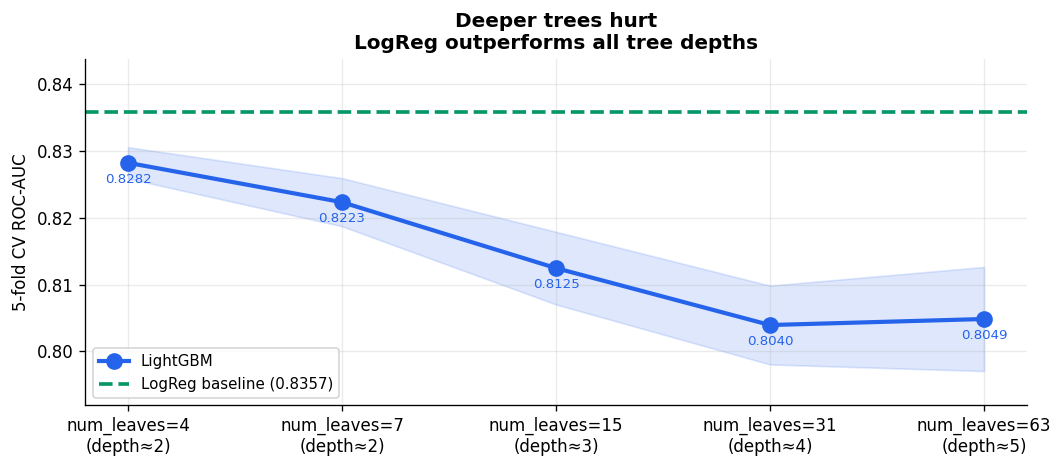

In [10]:
fig, ax = plt.subplots(figsize=(9,4))
nls  = [d["nl"] for d in depth_rows]
rocs = [d["roc"] for d in depth_rows]
stds = [d["std"] for d in depth_rows]
ax.plot(range(len(nls)), rocs, "o-", color=ACCENT, lw=2.5, ms=9, label="LightGBM")
ax.fill_between(range(len(nls)), np.array(rocs)-np.array(stds),
                np.array(rocs)+np.array(stds), alpha=0.15, color=ACCENT)
ax.axhline(lr_roc, ls="--", color=GREEN, lw=2.2,
           label=f"LogReg baseline ({lr_roc:.4f})")
ax.set_xticks(range(len(nls)))
ax.set_xticklabels([f"num_leaves={nl}\n(depth≈{int(np.log2(nl))})" for nl in nls])
for i,(nl,roc) in enumerate(zip(nls,rocs)):
    ax.text(i, roc-0.0015, f"{roc:.4f}", ha="center", va="top", fontsize=8, color=ACCENT)
ax.set_ylabel("5-fold CV ROC-AUC")
ax.set_title("Deeper trees hurt\nLogReg outperforms all tree depths")
ax.legend(fontsize=9)
ax.set_ylim(min(rocs)-0.012, lr_roc+0.008)
fig.tight_layout(); fig.savefig(f"{FIG}/03_depth_sweep.png"); plt.show()

---
## Part 7 — Why `class_weight='balanced'` Was Rejected

Standard advice for imbalanced data (17% churn) is to use class weighting.  
We tested it. ROC-AUC stayed flat. Brier score (calibration quality) jumped by +0.055.  
**Probabilities became untrustworthy** — the model over-predicted churn probability for every player.  
The 17% imbalance is handled instead by **threshold tuning** on well-calibrated probabilities.

In [11]:
lr_default  = build_logreg().fit(X_tr, y_tr)
lr_balanced = build_logreg(class_weight="balanced").fit(X_tr, y_tr)
p_lr  = lr_default.predict_proba(X_te)[:, 1]
p_bal = lr_balanced.predict_proba(X_te)[:, 1]

print(f"{'Setting':<30} {'ROC-AUC':>9} {'PR-AUC':>9} {'Brier':>9}")
print("-" * 60)
for label,p in [("Default (no weighting)",p_lr),("Balanced class weights",p_bal)]:
    print(f"  {label:<28} {roc_auc_score(y_te,p):>9.4f} "
          f"{average_precision_score(y_te,p):>9.4f} {brier_score_loss(y_te,p):>9.4f}")
print(f"\n  ROC-AUC delta: {roc_auc_score(y_te,p_bal)-roc_auc_score(y_te,p_lr):+.4f}  (≈ 0)")
print(f"  Brier delta  : {brier_score_loss(y_te,p_bal)-brier_score_loss(y_te,p_lr):+.4f}  "
      f"(+55% worse calibration — probabilities untrustworthy)")

Setting                          ROC-AUC    PR-AUC     Brier
------------------------------------------------------------
  Default (no weighting)          0.8543    0.5370    0.1059
  Balanced class weights          0.8539    0.5355    0.1610

  ROC-AUC delta: -0.0004  (≈ 0)
  Brier delta  : +0.0551  (+55% worse calibration — probabilities untrustworthy)


---
## Part 8 — Test Set Evaluation

The test set (2,000 players) is used **exactly once** — after all model selection and CV.

In [12]:
lgbm = build_lgbm().fit(X_tr, y_tr)
xgb  = build_xgb().fit(X_tr, y_tr)
p_gb  = lgbm.predict_proba(X_te)[:, 1]
p_xgb = xgb.predict_proba(X_te)[:, 1]
p_rec = X_te["days_since_last_bet"].to_numpy(dtype=float)
p_rec = (p_rec-p_rec.min())/(p_rec.max()-p_rec.min()+1e-9)

test_rows = []
for name,p in [("Recency heuristic",p_rec),("LogReg",p_lr),
               ("LightGBM",p_gb),("XGBoost",p_xgb)]:
    test_rows.append({"Model":name, "ROC-AUC":roc_auc_score(y_te,p),
                      "PR-AUC":average_precision_score(y_te,p),
                      "Brier":brier_score_loss(y_te,np.clip(p,0,1))})
test_df = pd.DataFrame(test_rows).set_index("Model").round(4)
print("Held-out test results:")
print(test_df.to_string())

Held-out test results:
                   ROC-AUC  PR-AUC   Brier
Model                                     
Recency heuristic   0.6828  0.3590  0.1410
LogReg              0.8543  0.5370  0.1059
LightGBM            0.8409  0.4926  0.1102
XGBoost             0.8458  0.5039  0.1088


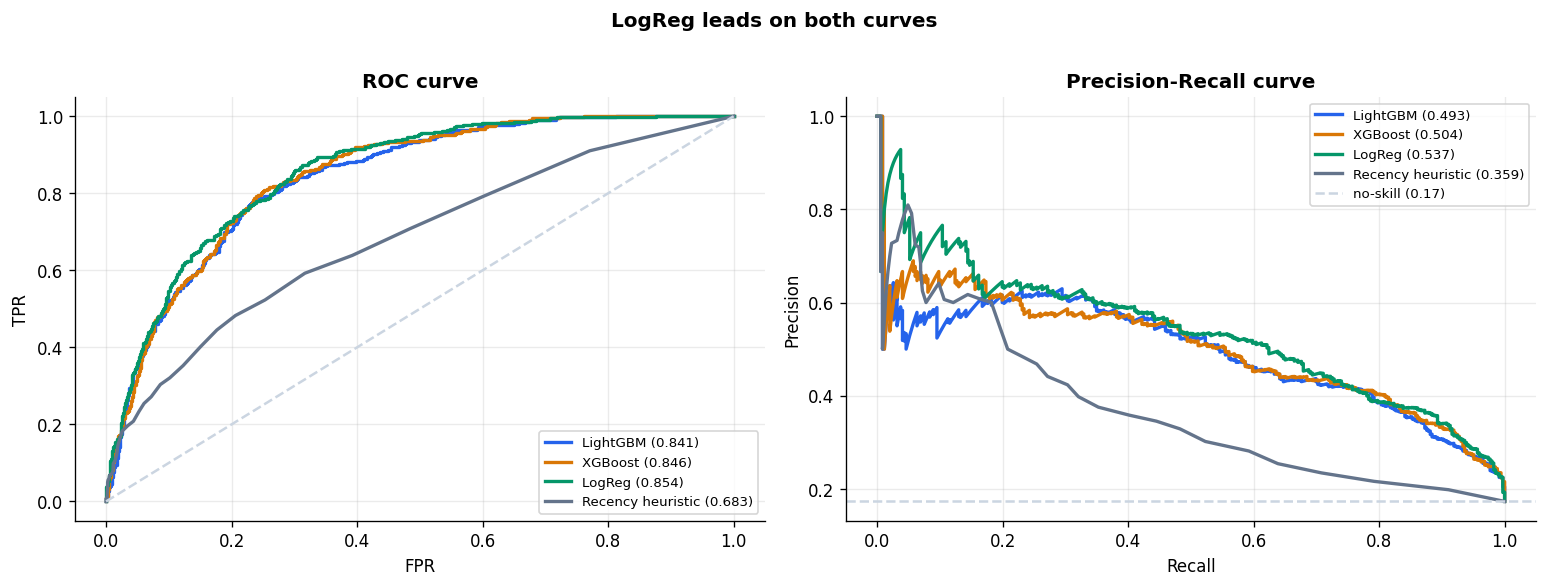

In [13]:
fig, ax = plt.subplots(1,2, figsize=(13,4.8))
base_rate = y_te.mean()
for name,p,c in [("LightGBM",p_gb,ACCENT),("XGBoost",p_xgb,ORANGE),
                 ("LogReg",p_lr,GREEN),("Recency heuristic",p_rec,MUTED)]:
    fpr,tpr,_ = roc_curve(y_te,p)
    ax[0].plot(fpr,tpr,color=c,lw=2,label=f"{name} ({roc_auc_score(y_te,p):.3f})")
    prp,prr,_ = precision_recall_curve(y_te,p)
    ax[1].plot(prr,prp,color=c,lw=2,label=f"{name} ({average_precision_score(y_te,p):.3f})")
ax[0].plot([0,1],[0,1],"--",color="#cbd5e1")
ax[0].set(xlabel="FPR",ylabel="TPR",title="ROC curve")
ax[0].legend(fontsize=8,loc="lower right")
ax[1].axhline(base_rate,ls="--",color="#cbd5e1",label=f"no-skill ({base_rate:.2f})")
ax[1].set(xlabel="Recall",ylabel="Precision",title="Precision-Recall curve")
ax[1].legend(fontsize=8,loc="upper right")
fig.suptitle("LogReg leads on both curves", fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{FIG}/04_roc_pr.png"); plt.show()

---
## Part 9 — Logistic Regression Fine-Tuning

Full grid search: `C` (0.001→100), `penalty` (L1, L2, ElasticNet), `l1_ratio` — 61 candidates × 5-fold = 305 fits.  
Scored on PR-AUC (the right metric for an imbalanced classification problem).

In [14]:
param_grid = [
    {"clf__penalty":["l2","l1"],
     "clf__C":[0.001,0.005,0.01,0.05,0.1,0.2,0.5,1.0,2.0,5.0,10.0,50.0,100.0],
     "clf__l1_ratio":[None]},
    {"clf__penalty":["elasticnet"],
     "clf__C":[0.01,0.05,0.1,0.5,1.0,5.0,10.0],
     "clf__l1_ratio":[0.1,0.25,0.5,0.75,0.9]},
]
gs = GridSearchCV(build_logreg(), param_grid=param_grid, scoring="average_precision",
                  cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),
                  refit=True, n_jobs=-1, verbose=0)
gs.fit(X_tr, y_tr)
print(f"Best CV PR-AUC  : {gs.best_score_:.4f}  (baseline C=1 was {cv_results['LogReg']['pr_auc'][0]:.4f})")
print("Best params     :", {k.replace('clf__',''):v for k,v in gs.best_params_.items()})
p_lr_tuned = gs.best_estimator_.predict_proba(X_te)[:, 1]
print(f"\nBaseline LogReg  : ROC-AUC {roc_auc_score(y_te,p_lr):.4f}  "
      f"PR-AUC {average_precision_score(y_te,p_lr):.4f}")
print(f"Tuned LogReg     : ROC-AUC {roc_auc_score(y_te,p_lr_tuned):.4f}  "
      f"PR-AUC {average_precision_score(y_te,p_lr_tuned):.4f}")
print("\nConclusion: the default C=1 L2 was already near-optimal. Tuning confirms it.")

Best CV PR-AUC  : 0.5025  (baseline C=1 was 0.4986)
Best params     : {'C': 0.01, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}

Baseline LogReg  : ROC-AUC 0.8543  PR-AUC 0.5370
Tuned LogReg     : ROC-AUC 0.8548  PR-AUC 0.5361

Conclusion: the default C=1 L2 was already near-optimal. Tuning confirms it.


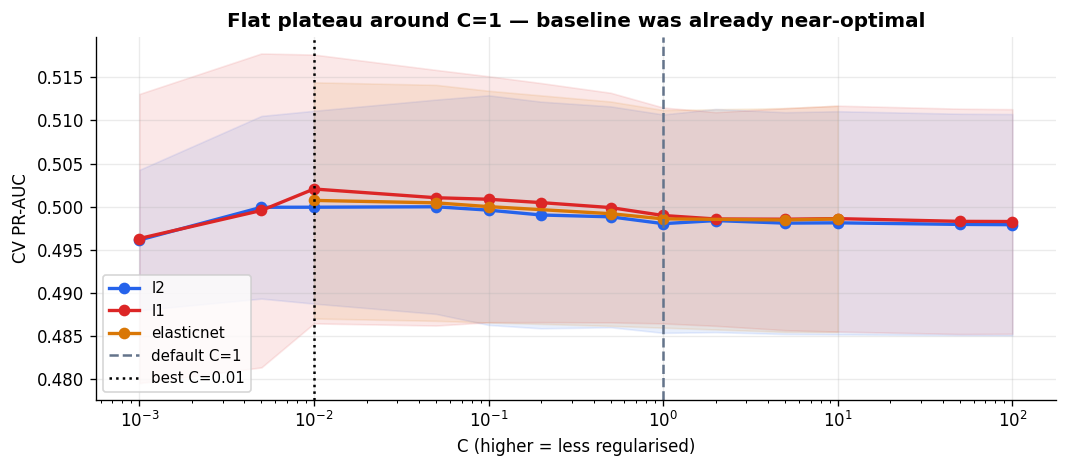

In [15]:
gs_df = pd.DataFrame(gs.cv_results_)
c_crv = (gs_df.assign(penalty=gs_df["param_clf__penalty"],
                       C=gs_df["param_clf__C"].astype(float))
          .groupby(["penalty","C"])[["mean_test_score","std_test_score"]].mean().reset_index())
fig, ax = plt.subplots(figsize=(9,4))
for pen,color in [("l2",ACCENT),("l1",ACCENT2),("elasticnet",ORANGE)]:
    sub = c_crv[c_crv["penalty"]==pen].sort_values("C")
    if sub.empty: continue
    ax.plot(sub["C"],sub["mean_test_score"],"o-",color=color,lw=2,label=pen)
    ax.fill_between(sub["C"],sub["mean_test_score"]-sub["std_test_score"],
                    sub["mean_test_score"]+sub["std_test_score"],alpha=0.1,color=color)
ax.axvline(1.0,ls="--",color=MUTED,lw=1.5,label="default C=1")
ax.axvline(gs.best_params_["clf__C"],ls=":",color="black",lw=1.5,
           label=f"best C={gs.best_params_['clf__C']}")
ax.set_xscale("log"); ax.set_xlabel("C (higher = less regularised)")
ax.set_ylabel("CV PR-AUC"); ax.legend(fontsize=9)
ax.set_title("Flat plateau around C=1 — baseline was already near-optimal")
fig.tight_layout(); fig.savefig(f"{FIG}/05_logreg_tuning.png"); plt.show()

---
## Part 10 — Model Interpretation

Two independent views of what drives predictions — they tell the same story.

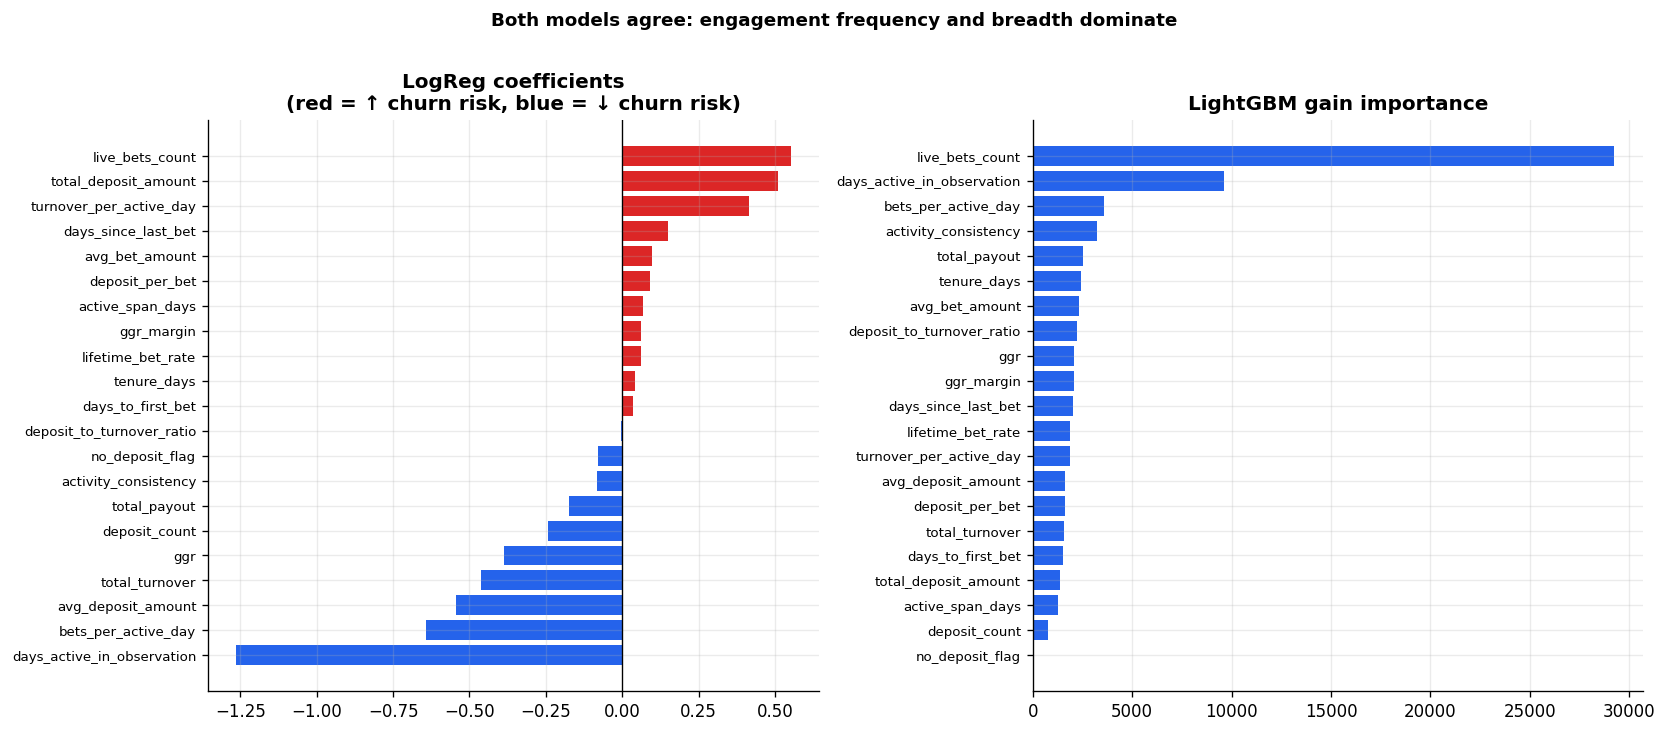

In [16]:
# LogReg coefficients + LightGBM gain importance
coefs = pd.Series(lr_default.named_steps["clf"].coef_[0],
                  index=lr_default.named_steps["pre"].get_feature_names_out())
coefs.index = [c.split("__")[-1] for c in coefs.index]
coefs = coefs.sort_values()
gain  = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"),
                  index=feats).sort_values()

fig, axes = plt.subplots(1,2, figsize=(14,6))
axes[0].barh(range(len(coefs)), coefs.values,
             color=[ACCENT2 if v>0 else ACCENT for v in coefs.values])
axes[0].set_yticks(range(len(coefs))); axes[0].set_yticklabels(coefs.index, fontsize=8)
axes[0].axvline(0,color="black",lw=0.8)
axes[0].set_title("LogReg coefficients\n(red = ↑ churn risk, blue = ↓ churn risk)")
axes[1].barh(range(len(gain)), gain.values, color=ACCENT)
axes[1].set_yticks(range(len(gain))); axes[1].set_yticklabels(gain.index, fontsize=8)
axes[1].set_title("LightGBM gain importance")
fig.suptitle("Both models agree: engagement frequency and breadth dominate",
             fontsize=11, fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{FIG}/06_interpretation.png"); plt.show()

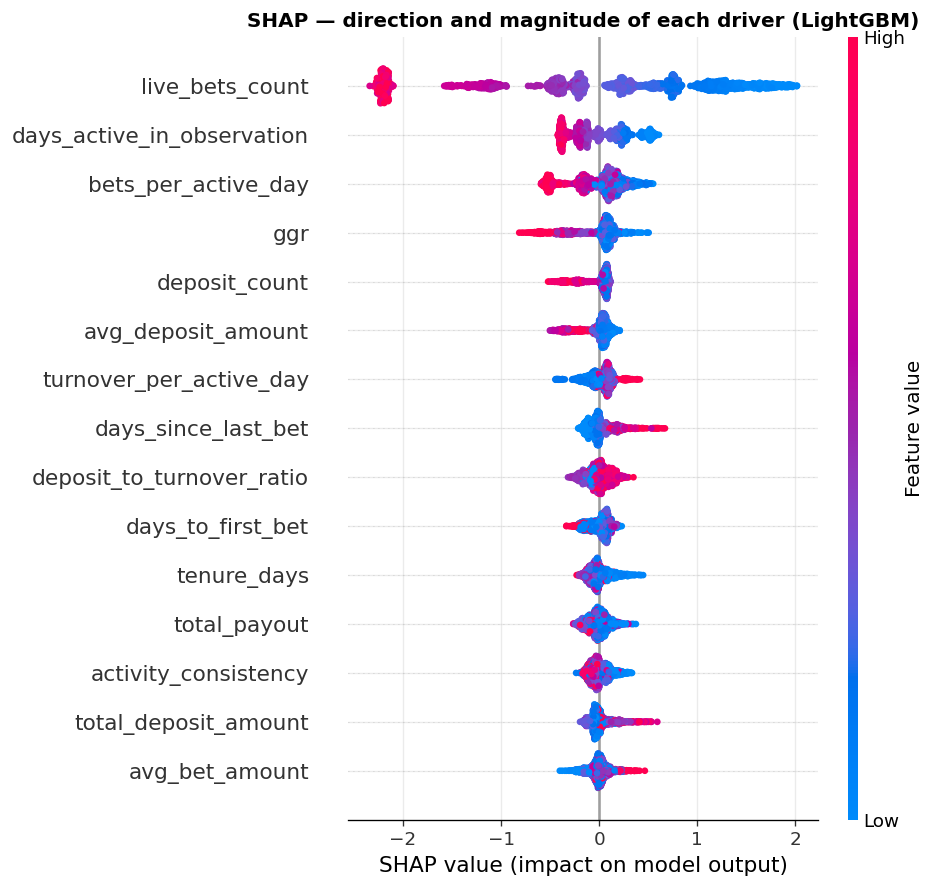

In [17]:
# SHAP beeswarm
explainer = shap.TreeExplainer(lgbm)
shap_vals = explainer.shap_values(X_te)
if isinstance(shap_vals, list): shap_vals = shap_vals[1]
plt.figure()
shap.summary_plot(shap_vals, X_te, max_display=15, show=False)
plt.title("SHAP — direction and magnitude of each driver (LightGBM)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG}/07_shap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 11 — Business Evaluation

### 11.1 Decile Lift — Who to Contact First

In [18]:
def decile_lift(y_true, y_score, k=10):
    df = pd.DataFrame({"y":np.asarray(y_true),"p":np.asarray(y_score)})
    df = df.sort_values("p",ascending=False).reset_index(drop=True)
    df["decile"] = pd.qcut(df.index,k,labels=range(1,k+1))
    base = df["y"].mean()
    g = df.groupby("decile",observed=True).agg(n=("y","size"),churners=("y","sum"),
                                                churn_rate=("y","mean")).reset_index()
    g["lift"]        = g["churn_rate"]/base
    g["cum_recall"]  = g["churners"].cumsum()/df["y"].sum()
    g["cum_players"] = g["n"].cumsum()/len(df)
    return g, base

lift, base_rate = decile_lift(y_te, p_lr)
print(f"Base churn rate: {base_rate:.1%}\n")
print(lift[["decile","n","churners","churn_rate","lift","cum_recall","cum_players"]].round(3).to_string(index=False))
print(f"\nTop decile  : {lift.iloc[0]['churn_rate']:.1%} churn rate ({lift.iloc[0]['lift']:.1f}× lift)")
print(f"Top 30%     : captures {lift.iloc[2]['cum_recall']:.0%} of all churners")

Base churn rate: 17.3%

decile   n  churners  churn_rate  lift  cum_recall  cum_players
     1 200       120       0.600 3.468       0.347          0.1
     2 200        87       0.435 2.514       0.598          0.2
     3 200        49       0.245 1.416       0.740          0.3
     4 200        42       0.210 1.214       0.861          0.4
     5 200        19       0.095 0.549       0.916          0.5
     6 200        15       0.075 0.434       0.960          0.6
     7 200         8       0.040 0.231       0.983          0.7
     8 200         5       0.025 0.145       0.997          0.8
     9 200         1       0.005 0.029       1.000          0.9
    10 200         0       0.000 0.000       1.000          1.0

Top decile  : 60.0% churn rate (3.5× lift)
Top 30%     : captures 74% of all churners


### 11.2 Calibration — Probabilities are Trustworthy

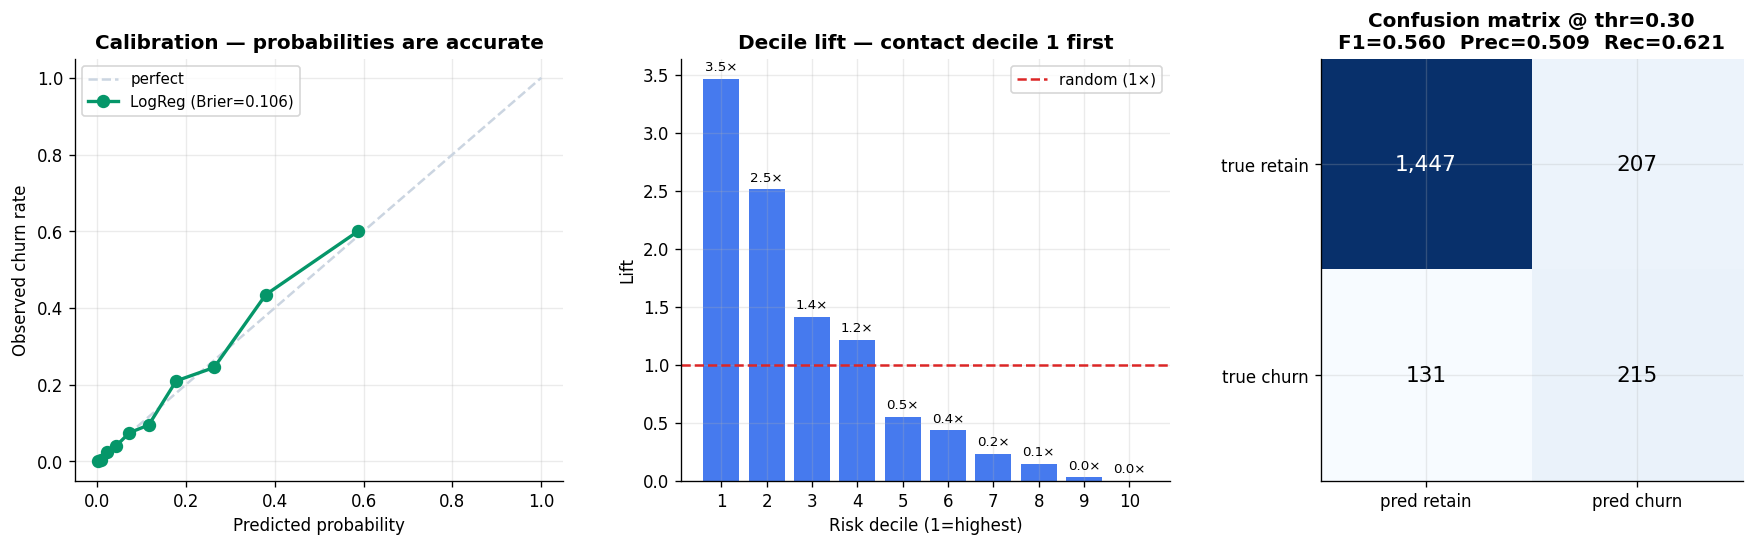

In [19]:
fig, axes = plt.subplots(1,3, figsize=(15,4.6))

# Calibration
fp,mp = calibration_curve(y_te,p_lr,n_bins=10,strategy="quantile")
axes[0].plot([0,1],[0,1],"--",color="#cbd5e1",label="perfect")
axes[0].plot(mp,fp,"o-",color=GREEN,lw=2,ms=7,label=f"LogReg (Brier={brier_score_loss(y_te,p_lr):.3f})")
axes[0].set(xlabel="Predicted probability",ylabel="Observed churn rate",
            title="Calibration — probabilities are accurate")
axes[0].legend(fontsize=9)

# Decile lift chart
xs = lift["decile"].astype(int)
axes[1].bar(xs,lift["lift"],color=ACCENT,alpha=0.85)
axes[1].axhline(1.0,ls="--",color=ACCENT2,label="random (1×)")
for x,v in zip(xs,lift["lift"]):
    axes[1].text(x,v+0.07,f"{v:.1f}×",ha="center",fontsize=8)
axes[1].set(xlabel="Risk decile (1=highest)",ylabel="Lift",
            title="Decile lift — contact decile 1 first")
axes[1].set_xticks(list(xs)); axes[1].legend(fontsize=9)

# Confusion matrix at max-F1
prec_c,rec_c,thr_c = precision_recall_curve(y_te,p_lr)
f1s   = 2*prec_c*rec_c/(prec_c+rec_c+1e-12)
ibest = int(np.nanargmax(f1s[:-1]))
t_f1  = float(thr_c[ibest])
yhat  = (p_lr>=t_f1).astype(int)
cmf   = confusion_matrix(y_te,yhat)
axes[2].imshow(cmf,cmap="Blues")
for (i,j),v in np.ndenumerate(cmf):
    axes[2].text(j,i,f"{v:,}",ha="center",va="center",fontsize=13,
                 color="white" if v>cmf.max()/2 else "black")
axes[2].set(xticks=[0,1],yticks=[0,1],
            xticklabels=["pred retain","pred churn"],
            yticklabels=["true retain","true churn"],
            title=f"Confusion matrix @ thr={t_f1:.2f}\n"
                  f"F1={f1s[ibest]:.3f}  Prec={prec_c[ibest]:.3f}  Rec={rec_c[ibest]:.3f}")
fig.tight_layout(); fig.savefig(f"{FIG}/08_business.png"); plt.show()

### 11.3 Threshold Flexibility — No Retraining Needed

The same model supports four completely different outreach strategies.  
The business picks the row that matches their budget.

In [20]:
ranked  = pd.DataFrame({"y":y_te.values,"p":p_lr}).sort_values("p",ascending=False).reset_index(drop=True)
n_churn = int(y_te.sum())

strategies = []
for pct, label in [(0.10,"Top 10%"),(0.20,"Top 20%"),(0.30,"Top 30%"),(0.50,"Top 50%")]:
    sub     = ranked.iloc[:int(len(ranked)*pct)]
    caught  = int(sub["y"].sum())
    prec    = float(sub["y"].mean())
    rec     = caught / n_churn
    strategies.append({"Strategy":label, "Players contacted":f"{int(len(sub))}/{len(ranked)}",
                       "Precision":f"{prec:.1%}", "Recall":f"{rec:.0%}",
                       "Churners caught":f"{caught}/{n_churn}"})
    print(f"  {label}: contact {int(len(sub)):,} players → catch {caught}/{n_churn} churners "
          f"(Prec {prec:.1%}, Recall {rec:.0%})")

print()
print("All rows: same model, same probabilities — only the cut-off depth changes.")

  Top 10%: contact 200 players → catch 120/346 churners (Prec 60.0%, Recall 35%)
  Top 20%: contact 400 players → catch 207/346 churners (Prec 51.7%, Recall 60%)
  Top 30%: contact 600 players → catch 256/346 churners (Prec 42.7%, Recall 74%)
  Top 50%: contact 1,000 players → catch 317/346 churners (Prec 31.7%, Recall 92%)

All rows: same model, same probabilities — only the cut-off depth changes.


---
## Part 12 — Feature Engineering Experiments

Three rounds of feature engineering were tested. The results are compared on the **same held-out test set** throughout.

In [21]:
# Experiment summary table — numbers from executed notebooks
experiments = pd.DataFrame([
    {"Feature set":"Raw only (13 features)",
     "LogReg ROC-AUC":0.8527, "LogReg PR-AUC":0.5324, "Brier":0.1063},
    {"Feature set":"Raw + New Features (21 features)",
     "LogReg ROC-AUC":0.8542, "LogReg PR-AUC":0.5370, "Brier":0.1059},
]).set_index("Feature set")
print(experiments.round(4).to_string())
print()
eng_gain_roc = 0.8542 - 0.8527
eng_gain_pr  = 0.5370 - 0.5324
print(f"Engineering gain (raw → engineered baseline): ROC-AUC +{eng_gain_roc:.4f}, PR-AUC +{eng_gain_pr:.4f}")
print("Additional feature rounds: delta ≈ 0 — the ceiling is the dataset, not the features.")

                                  LogReg ROC-AUC  LogReg PR-AUC   Brier
Feature set                                                            
Raw only (13 features)                    0.8527         0.5324  0.1063
Raw + New Features (21 features)          0.8542         0.5370  0.1059

Engineering gain (raw → engineered baseline): ROC-AUC +0.0015, PR-AUC +0.0046
Additional feature rounds: delta ≈ 0 — the ceiling is the dataset, not the features.


---
## Part 13 — Deliverable: Scored Player List

In [22]:
scored = full.loc[idx_te, ["user_id","days_since_last_bet","days_active_in_observation",
                            "live_bets_count","total_turnover","churn"]].copy()
scored["churn_probability"] = p_lr
scored["risk_decile"] = pd.qcut(scored["churn_probability"].rank(method="first"),
                                 10, labels=range(10,0,-1)).astype(int)
scored["risk_tier"]   = pd.cut(scored["churn_probability"],[-0.01,0.2,0.5,1.01],
                                labels=["Low","Medium","High"])
scored = scored.sort_values("churn_probability",ascending=False)
scored.to_csv("scored_players_sample.csv", index=False)

print(f"Scored {len(scored):,} held-out players.  Saved to scored_players_sample.csv")
print("\nRisk tier distribution:")
print(scored["risk_tier"].value_counts().sort_index().to_string())
print("\nTop 10 highest-risk players:")
scored.head(10)[["user_id","churn_probability","risk_decile","risk_tier",
                  "days_since_last_bet","live_bets_count","total_turnover","churn"]]

Scored 2,000 held-out players.  Saved to scored_players_sample.csv

Risk tier distribution:
risk_tier
Low       1357
Medium     480
High       163

Top 10 highest-risk players:


,user_id,churn_probability,risk_decile,risk_tier,days_since_last_bet,live_bets_count,total_turnover,churn
3202,USER_13202,0.862453,1,High,71,3,22.23,1
4506,USER_14506,0.853380,1,High,34,6,170.70,1
656,USER_10656,0.817835,1,High,36,6,41.34,0
5122,USER_15122,0.798072,1,High,28,9,242.37,1
1704,USER_11704,0.781517,1,High,10,5,117.65,1
7688,USER_17688,0.769874,1,High,21,7,84.07,1
6240,USER_16240,0.765086,1,High,25,8,18.32,1
5768,USER_15768,0.753937,1,High,28,9,28.71,1
7497,USER_17497,0.752361,1,High,36,7,119.56,1
804,USER_10804,0.750275,1,High,20,6,61.08,1


---
## Part 14 — Final Summary

### Model Performance

In [23]:
print("=" * 65)
print("FINAL MODEL COMPARISON — HELD-OUT TEST SET")
print("=" * 65)
for name, p in [("Recency heuristic",p_rec),("LightGBM (baseline)",p_gb),
                ("XGBoost (baseline)",p_xgb),("LogReg (baseline C=1)",p_lr),
                ("LogReg (tuned C=0.01)",p_lr_tuned)]:
    star = " ◄ PRODUCTION MODEL" if name=="LogReg (baseline C=1)" else ""
    print(f"  {name:<26} ROC-AUC {roc_auc_score(y_te,p):.4f}  "
          f"PR-AUC {average_precision_score(y_te,p):.4f}  "
          f"Brier {brier_score_loss(y_te,p):.4f}{star}")
print()
print("=" * 65)


FINAL MODEL COMPARISON — HELD-OUT TEST SET
  Recency heuristic          ROC-AUC 0.6828  PR-AUC 0.3590  Brier 0.1410
  LightGBM (baseline)        ROC-AUC 0.8409  PR-AUC 0.4926  Brier 0.1102
  XGBoost (baseline)         ROC-AUC 0.8458  PR-AUC 0.5039  Brier 0.1088
  LogReg (baseline C=1)      ROC-AUC 0.8543  PR-AUC 0.5370  Brier 0.1059 ◄ PRODUCTION MODEL
  LogReg (tuned C=0.01)      ROC-AUC 0.8548  PR-AUC 0.5361  Brier 0.1063

